### <div class="alert alert-block alert-info"><b>Import library<b><div>


In [81]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries imported")

Libraries imported


### <div class="alert alert-block alert-info"><b>Load Dataset <b><div>


In [82]:

# Load Cleaned matche dataset
match_level=pd.read_csv( r"C:\Users\Akash\Downloads\Dataset\matches_cleaned.csv")

# Load Cleaned ipl_data dataset
ipl_data=pd.read_csv( r"C:\Users\Akash\Downloads\Dataset\ipl_dataset_cleaned.csv",low_memory=False)



### <div class="alert alert-block alert-info"><b>1.Venue-wise Toss Analysis<b><div>


In [83]:
# ==========================================
# TOSS DECISION PER VENUE
# ==========================================

venue_toss = match_level.groupby(

    ["venue", "toss_decision"]

)["match_id"].count().unstack()


# Convert to percentage

venue_toss_percent = venue_toss.div(

    venue_toss.sum(axis=1),

    axis=0

) * 100


# ==========================================
# VENUE POPULARITY (MOST MATCHES)
# ==========================================

venue_popularity = match_level.groupby(

    "venue"

)["match_id"].count()


# Sort descending

venue_popularity = venue_popularity.sort_values(

    ascending=False

)


venue_popularity.head(10)

venue
Wankhede Stadium, Mumbai                                  118
M. Chinnaswamy Stadium, Bengaluru                          94
Eden Gardens, Kolkata                                      93
MA Chidambaram Stadium, Chepauk, Chennai                   85
Rajiv Gandhi International Stadium, Uppal, Hyderabad       77
I.S. Bindra Punjab Cricket Association Stadium, Mohali     61
Feroz Shah Kotla                                           60
Sawai Mansingh Stadium, Jaipur                             57
Dubai International Cricket Stadium                        46
Dr DY Patil Sports Academy, Mumbai                         37
Name: match_id, dtype: int64

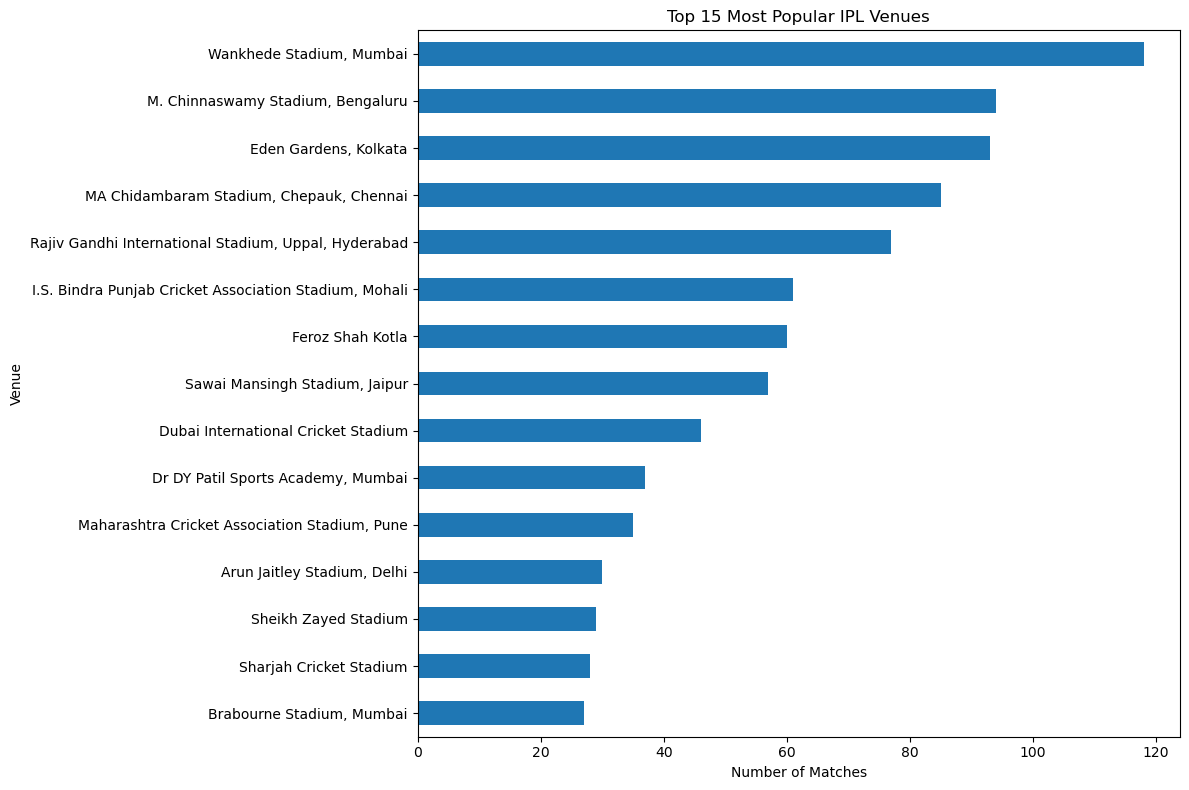

In [84]:
# ==========================================
# TOP 15 POPULAR VENUES Visulization
# ==========================================

top_venues = venue_popularity.head(15)


plt.figure(figsize=(12,8))


top_venues.sort_values().plot(

    kind="barh"

)


plt.title(

    "Top 15 Most Popular IPL Venues"

)

plt.xlabel("Number of Matches")

plt.ylabel("Venue")


plt.tight_layout()

plt.show()

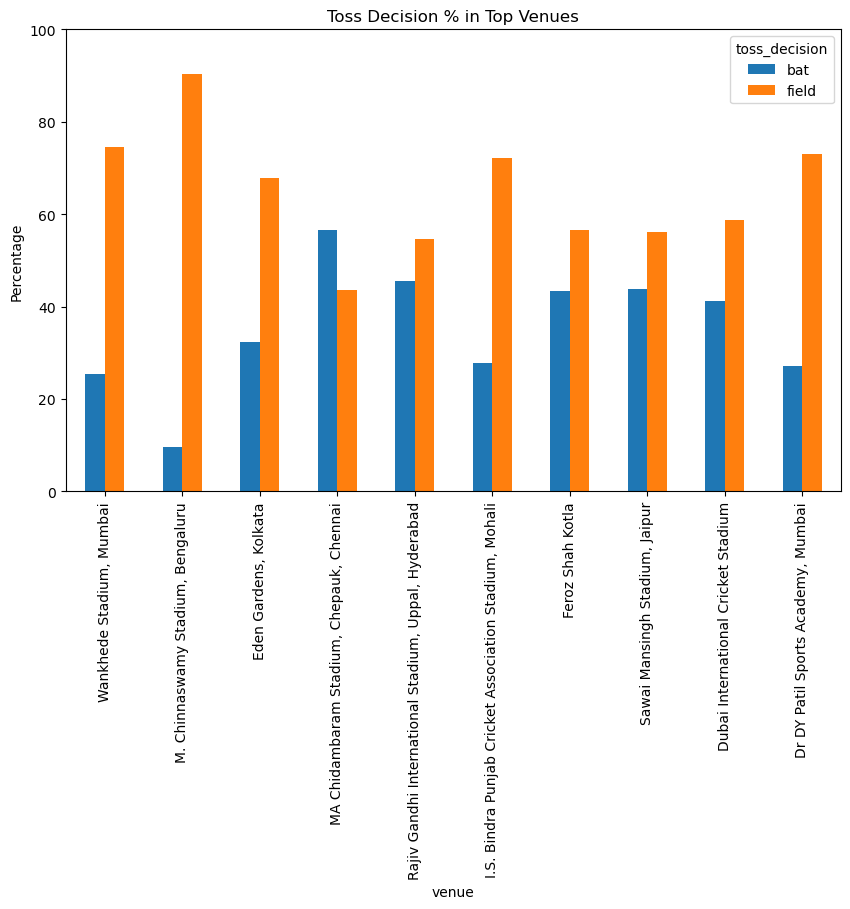

In [85]:
# ==========================================
# TOSS DECISION — TOP VENUES
# ==========================================

top_venue_names = venue_popularity.head(10).index


top_venue_toss = venue_toss_percent.loc[top_venue_names]


top_venue_toss.plot(

    kind="bar",

    figsize=(10,6)

)


plt.title("Toss Decision % in Top Venues")

plt.ylabel("Percentage")

plt.xticks(rotation=90)
plt.yticks(np.arange(0, 120, step=20))

plt.show()

### <div class="alert alert-block alert-info"><b>2.Pressure-Time Bowler Strategy<b><div>


In [86]:
# ==========================================
# FILTER DEATH OVERS
# ==========================================

death_overs = ipl_data[ipl_data["match_phase"] == "Death Overs"]


death_overs.shape

(44304, 39)

In [87]:
# ==========================================
# RUNS GIVEN IN DEATH OVERS
# ==========================================

death_runs = death_overs.groupby("bowler")["total_runs"].sum()
# .sort_values(ascending=True)


death_runs.head()

bowler
A Ashish Reddy    122
A Chandila          6
A Choudhary        31
A Flintoff         52
A Kumble          143
Name: total_runs, dtype: int64

In [88]:
# ==========================================
# BALLS BOWLED
# ==========================================

death_balls = death_overs.groupby("bowler")["ball"].count()

death_balls.head()

bowler
A Ashish Reddy     73
A Chandila          6
A Choudhary        24
A Flintoff         18
A Kumble          107
Name: ball, dtype: int64

In [89]:
# ==========================================
# ECONOMY RATE (DEATH OVERS)
# ==========================================

death_overs_count = death_balls / 6

death_economy = ( death_runs / death_overs_count)

death_economy.head()

bowler
A Ashish Reddy    10.027397
A Chandila         6.000000
A Choudhary        7.750000
A Flintoff        17.333333
A Kumble           8.018692
dtype: float64

In [90]:
# ==========================================
# WICKETS IN DEATH OVERS
# ==========================================

death_wickets = death_overs[

    death_overs["is_wicket"] == 1

].groupby(

    "bowler"

)["is_wicket"].count()


death_wickets.head()

bowler
A Ashish Reddy     8
A Choudhary        1
A Flintoff         1
A Kumble          14
A Mishra          28
Name: is_wicket, dtype: int64

In [91]:
# ==========================================
# COMBINE METRICS
# ==========================================

death_bowler_stats = pd.DataFrame({

    "Runs": death_runs,

    "Balls": death_balls,

    "Economy": death_economy,

    "Wickets": death_wickets

})


# Remove bowlers with few balls

death_bowler_stats = death_bowler_stats[

    death_bowler_stats["Balls"] >= 60

]


death_bowler_stats.head()

,Runs,Balls,Economy,Wickets
bowler,,,,
A Ashish Reddy,122,73,10.027397,8.0
A Kumble,143,107,8.018692,14.0
A Mishra,459,287,9.595819,28.0
A Mithun,149,78,11.461538,5.0
A Nehra,620,419,8.878282,49.0


In [92]:
# ==========================================
# TOP DEATH BOWLERS
# ==========================================

top_death_bowlers = death_bowler_stats.sort_values(

    by=["Economy", "Wickets"],

    ascending=[True, False]

).head(15)


top_death_bowlers

,Runs,Balls,Economy,Wickets
bowler,,,,
M Theekshana,74,66,6.727273,8.0
Sohail Tanvir,109,96,6.812500,17.0
DE Bollinger,264,210,7.542857,25.0
M Ashwin,91,72,7.583333,5.0
Harmeet Singh,128,100,7.680000,9.0
KH Pandya,122,94,7.787234,12.0
SL Malinga,1192,918,7.790850,101.0
Rashid Khan,407,312,7.826923,28.0
J Theron,118,90,7.866667,4.0


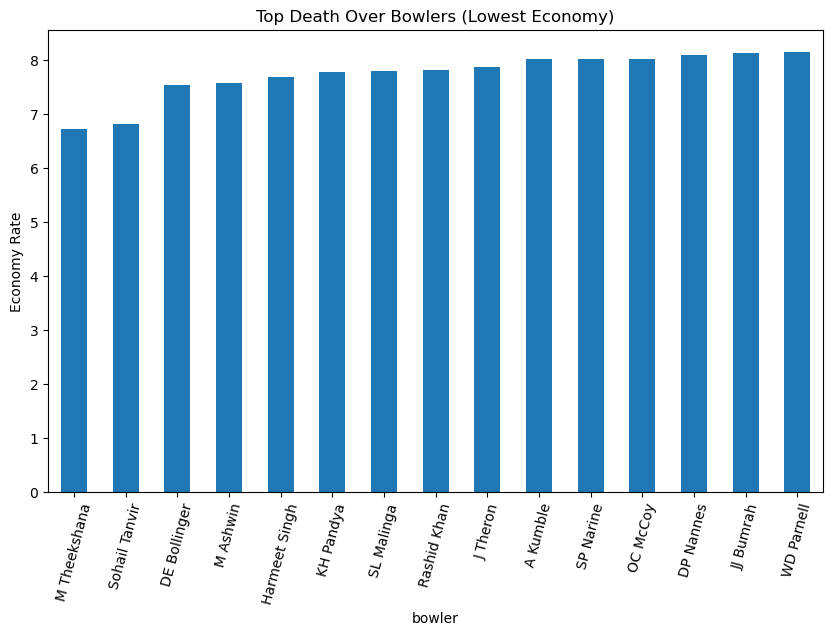

In [93]:
# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))

top_death_bowlers["Economy"].plot(

    kind="bar"
)

plt.title("Top Death Over Bowlers (Lowest Economy)")

plt.ylabel("Economy Rate")

plt.xticks(rotation=75)

plt.show()

### <div class="alert alert-block alert-info"><b>3.Venue wise Run Behaviour<b><div>


In [94]:
# ==========================================
# TOTAL RUNS PER MATCH
# ==========================================

match_runs = ipl_data.groupby(

    ["match_id", "venue"]

)["total_runs"].sum().reset_index()


match_runs.head()

,match_id,venue,total_runs
0,335982,"M. Chinnaswamy Stadium, Bengaluru",281
1,335983,I.S. Bindra Punjab Cricket Association Stadium...,437
2,335984,Feroz Shah Kotla,252
3,335985,"Wankhede Stadium, Mumbai",318
4,335986,"Eden Gardens, Kolkata",210


In [95]:
# ==========================================
# AVERAGE RUNS PER VENUE
# ==========================================

venue_avg_runs = match_runs.groupby( "venue")["total_runs"].mean()

venue_avg_runs.head()

venue
Arun Jaitley Stadium, Delhi                                              339.933333
Barabati Stadium                                                         319.285714
Barsapara Cricket Stadium, Guwahati                                      329.333333
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow    293.857143
Brabourne Stadium, Mumbai                                                329.370370
Name: total_runs, dtype: float64

In [96]:
# ==========================================
# SORT VENUES BY SCORING
# ==========================================

venue_avg_runs = venue_avg_runs.sort_values( ascending=False )

venue_avg_runs.head(10)

venue
Arun Jaitley Stadium, Delhi                                           339.933333
Brabourne Stadium, Mumbai                                             329.370370
Barsapara Cricket Stadium, Guwahati                                   329.333333
Narendra Modi Stadium, Ahmedabad                                      328.708333
Himachal Pradesh Cricket Association Stadium, Dharamsala              327.769231
Saurashtra Cricket Association Stadium                                321.500000
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur    320.800000
Barabati Stadium                                                      319.285714
Green Park                                                            318.000000
Wankhede Stadium, Mumbai                                              316.296610
Name: total_runs, dtype: float64

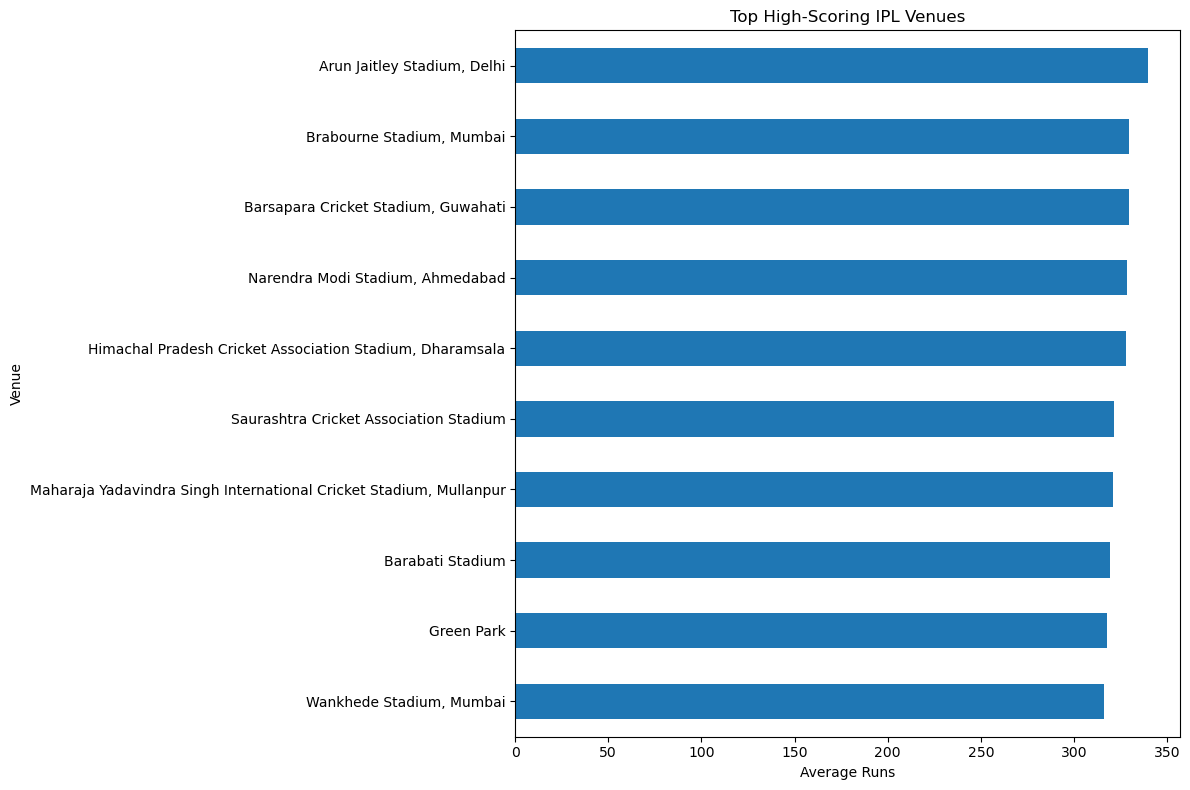

In [97]:
# ==========================================
# HIGH SCORING VENUES
# ==========================================

top_scoring = venue_avg_runs.head(10)

plt.figure(figsize=(12,8))

top_scoring.sort_values().plot( kind="barh" )

plt.title("Top High-Scoring IPL Venues")

plt.xlabel("Average Runs")

plt.ylabel("Venue")


plt.tight_layout()

plt.show()

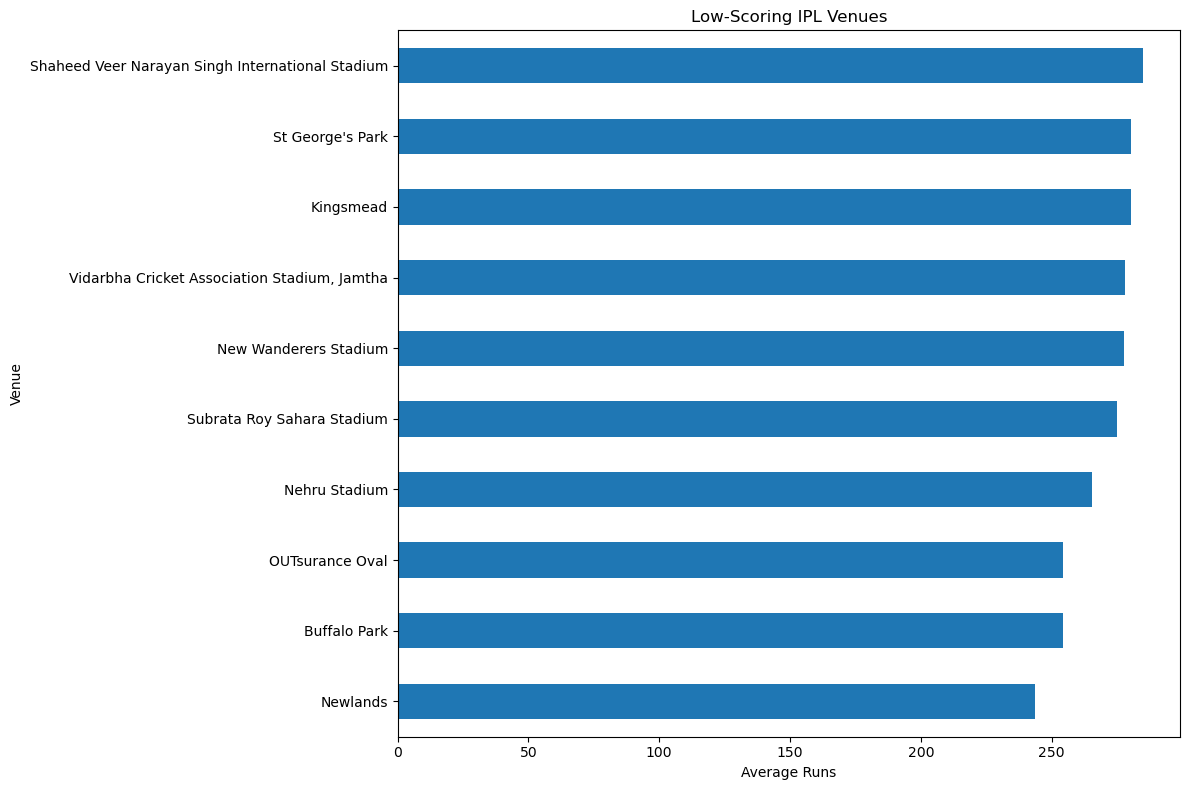

In [98]:
# ==========================================
# LOW SCORING VENUES
# ==========================================

low_scoring = venue_avg_runs.tail(10)

plt.figure(figsize=(12,8))

low_scoring.sort_values().plot( kind="barh")


plt.title("Low-Scoring IPL Venues")

plt.xlabel("Average Runs")

plt.ylabel("Venue")


plt.tight_layout()

plt.show()

In [99]:
# ==========================================
# VENUE CLASSIFICATION
# ==========================================

venue_class = pd.cut(

    venue_avg_runs,

    bins=[0,150,170,250],

    labels=[

        "Low Scoring",

        "Medium Scoring",

        "High Scoring"  ]
)


venue_class.value_counts()

total_runs
High Scoring      1
Low Scoring       0
Medium Scoring    0
Name: count, dtype: int64

In [ ]:
sam